In [ ]:
# ==========================
# Entorno PyMC + PreliZ para Colab actual
# ==========================

!pip uninstall -y \
    pymc \
    pytensor \
    preliz \
    arviz \
    arviz_stats \
    numba \
    llvmlite

!pip install -U --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.16.1" \
    "pandas==2.3.0" \
    "matplotlib==3.10.0" \
    "arviz==0.22.0" \
    "pymc==5.28.5" \
    "preliz==0.20.0"

print("\n==============================")
print("INSTALACIÓN TERMINADA")
print("Ahora hacé Runtime > Restart session")
print("y recién después ejecutá las demás celdas.")
print("==============================")

In [ ]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-doc")

#| code-fold: true

az.style.use('arviz-doc')

### 1. Datos observados
Supongamos que observamos 20 grupos y, en cada grupo, contamos cuántos éxitos hubo sobre 20 intentos.


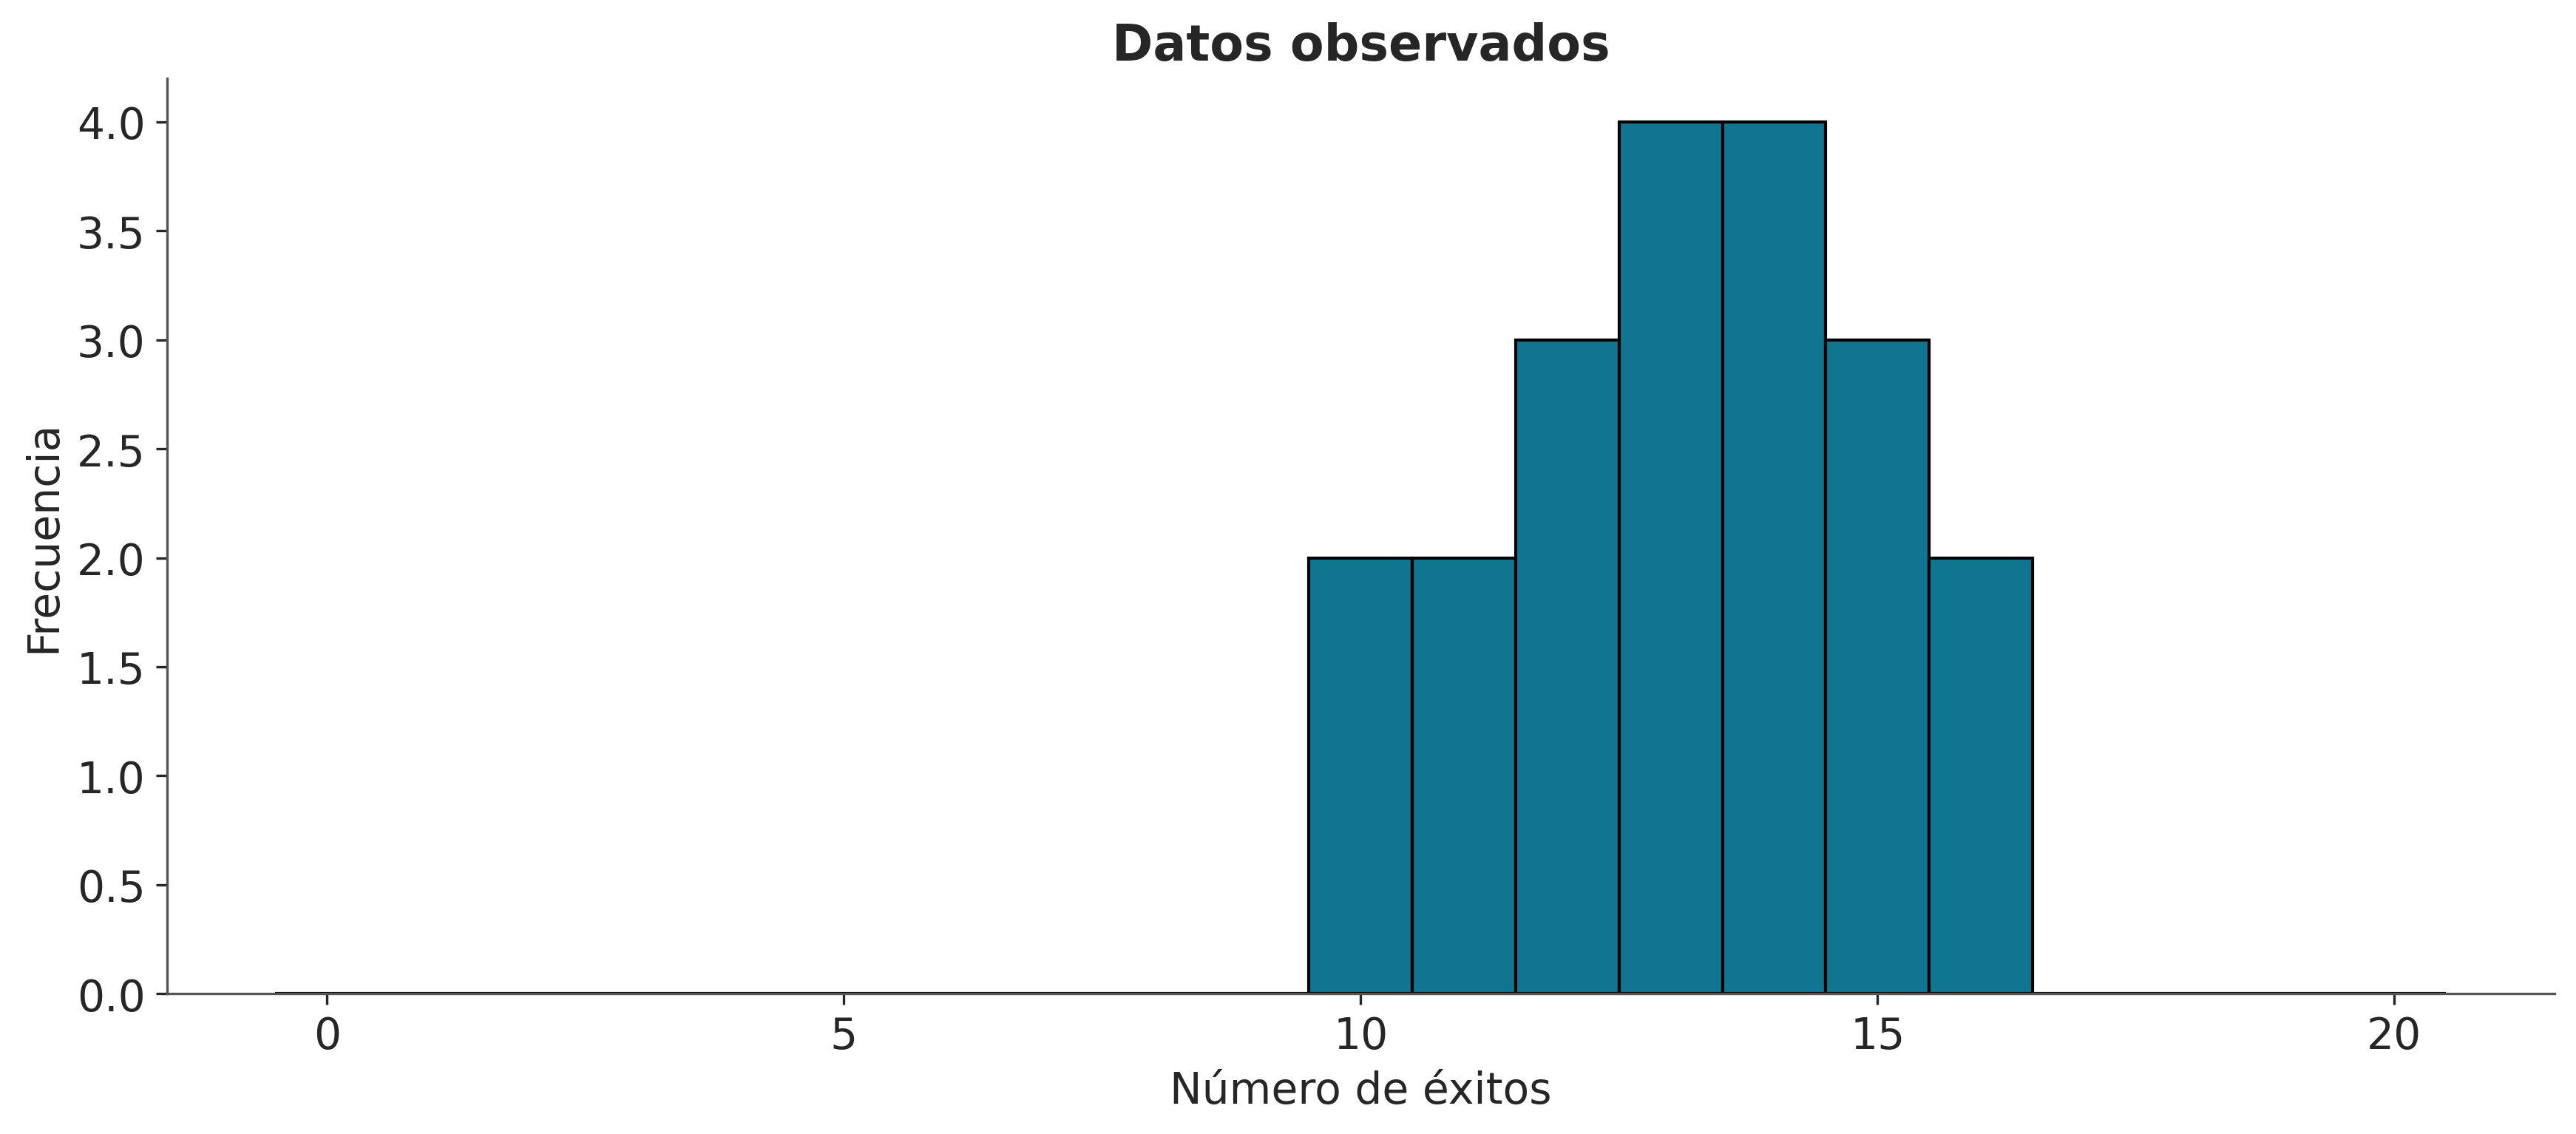

In [ ]:
np.random.seed(42)

y = np.array([
    12, 14, 11, 15, 13,
    16, 10, 14, 12, 13,
    15, 11, 14, 13, 12,
    16, 14, 10, 13, 15
])

n = 20

plt.hist(y, bins=np.arange(-0.5, 21.5, 1), edgecolor="black")
plt.xlabel("Número de éxitos")
plt.ylabel("Frecuencia")
plt.title("Datos observados")
plt.show()


Estos son nuestros datos observados. Ahora vamos a proponer un modelo para describirlos.


### 2. Predictiva a priori
Primero proponemos un modelo:


$$y_i​∼Binomial(20,p)$$

y, antes de ver los datos, suponemos:
$$p∼Beta(2,2)$$


Ahora simulamos datos solamente a partir del modelo y del prior.


In [ ]:
with pm.Model() as modelo_prior:

    p = pm.Beta("p", alpha=2, beta=2)

    y_prior = pm.Binomial(
        "y_prior",
        n=20,
        p=p
    )

    # Simulamos del prior
    prior_pred_raw = pm.sample_prior_predictive(
        samples=1000
    )

# Tomamos las simulaciones de y_prior
y_prior_sim = prior_pred_raw.prior["y_prior"].values

# Creamos un nuevo InferenceData con el grupo que queremos
prior_pred = az.InferenceData(
    prior=prior_pred_raw.prior,
    prior_predictive=az.convert_to_dataset(
        {"y_prior": y_prior_sim}
    )
)

In [ ]:
print(prior_pred.groups())

['prior', 'prior_predictive']


Podemos mirar qué tipo de datos genera nuestro modelo:


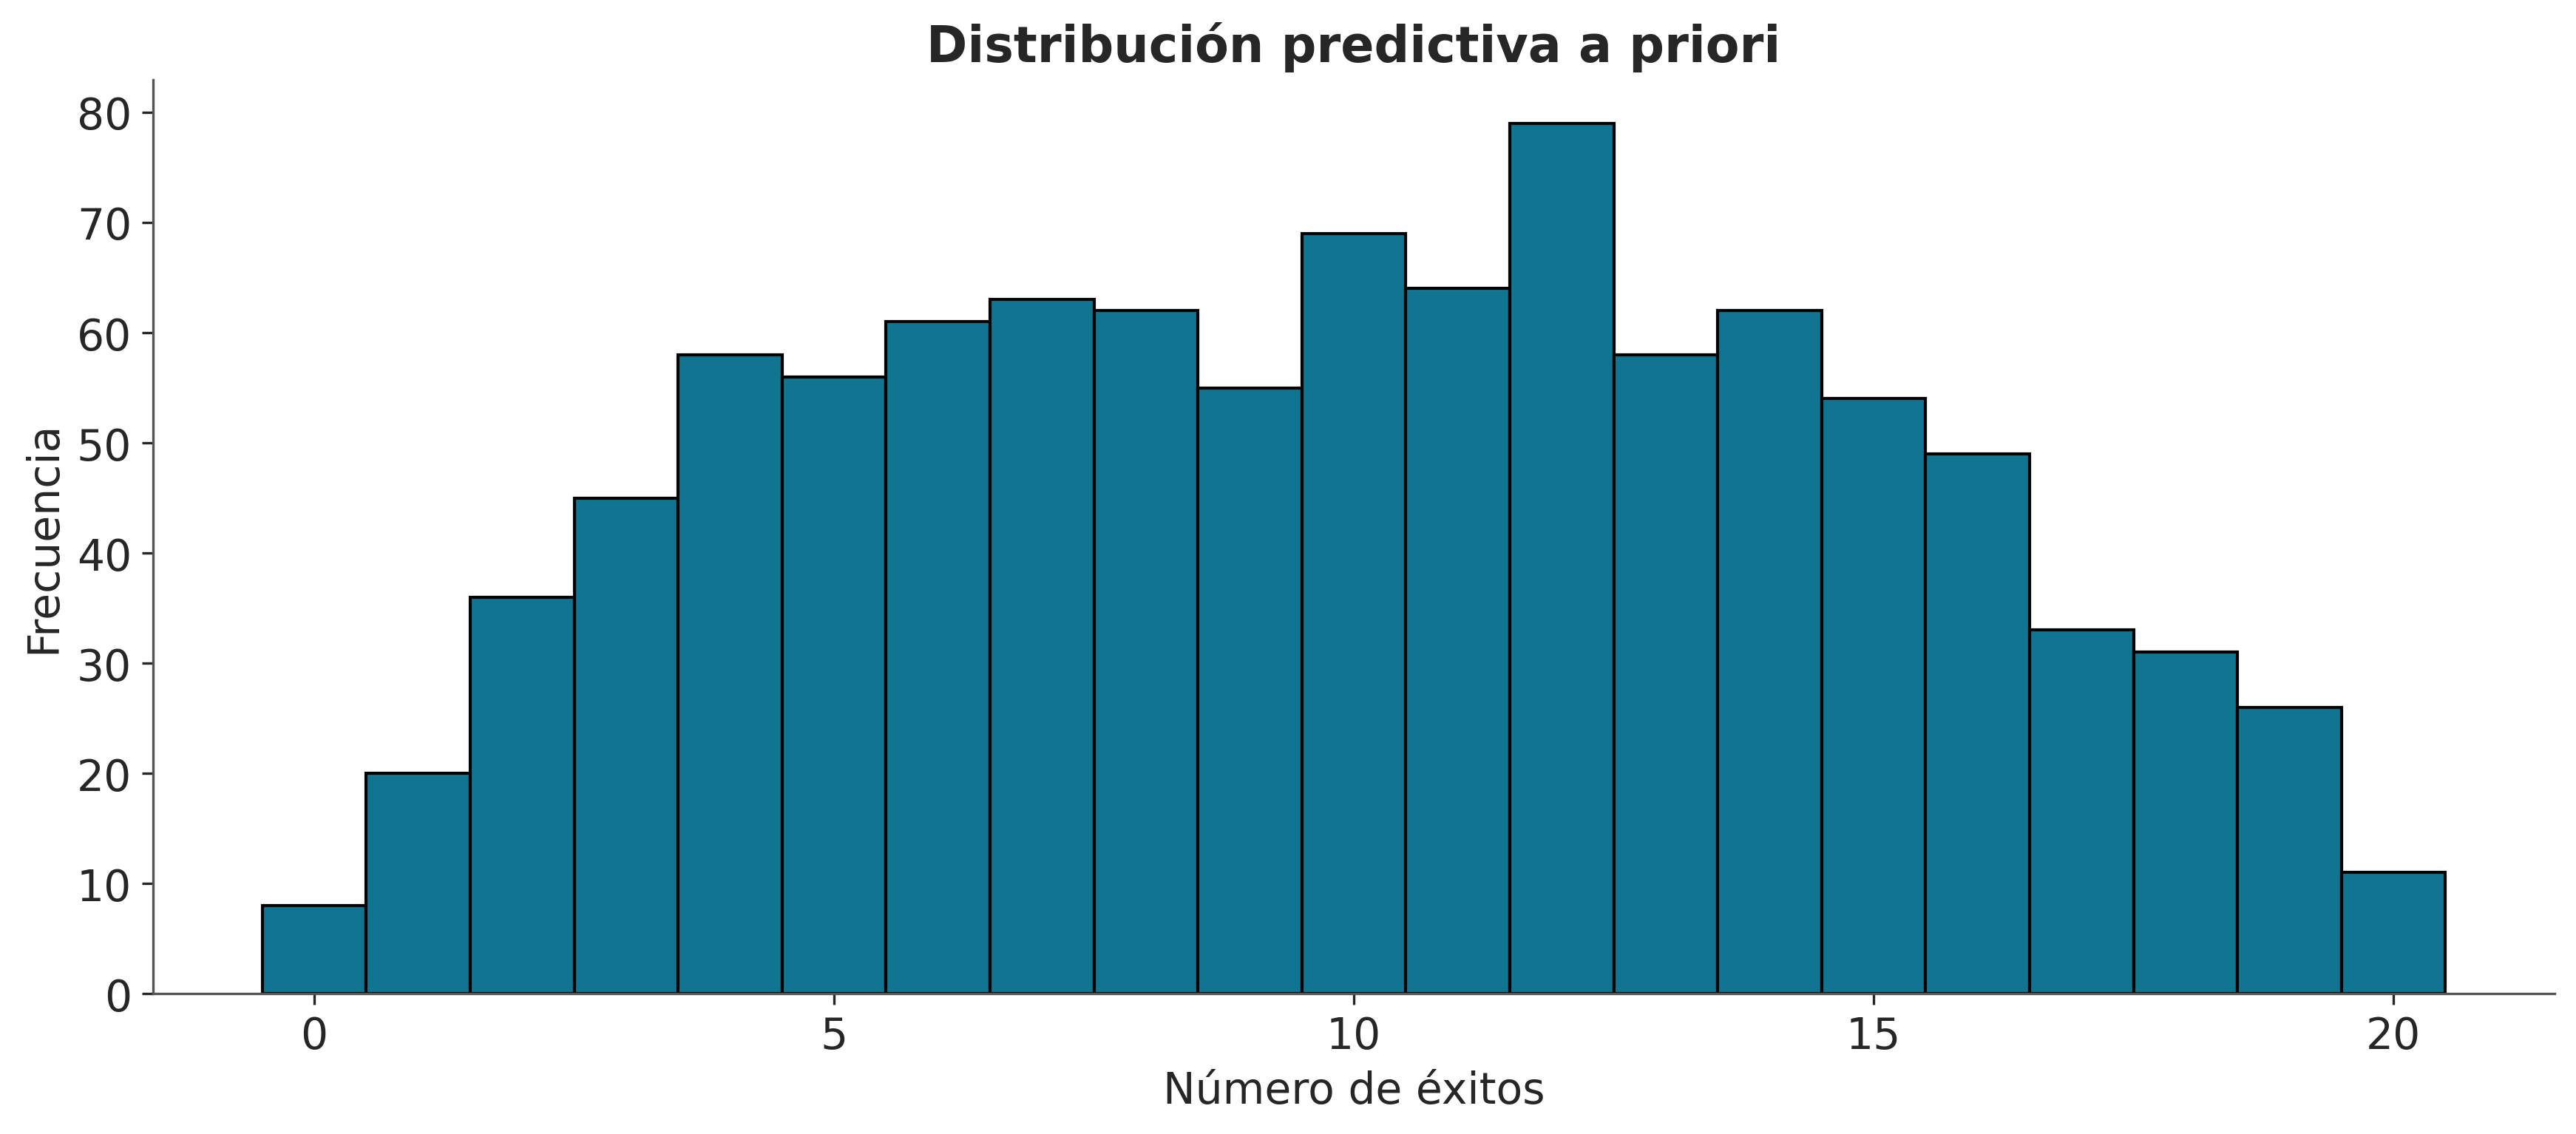

In [ ]:
y_prior_sim = prior_pred.prior_predictive["y_prior"].values.flatten()

plt.hist(
    y_prior_sim,
    bins=np.arange(-0.5, 21.5, 1),
    edgecolor="black"
)

plt.xlabel("Número de éxitos")
plt.ylabel("Frecuencia")
plt.title("Distribución predictiva a priori")

plt.show()


Todavía no usamos los datos observados para aprender sobre el parámetro. Simplemente estamos preguntándonos qué datos considera plausibles nuestro modelo antes de observarlos.


Si acá aparecieran valores que consideramos completamente absurdos para nuestro problema, entonces tendríamos que revisar el prior o directamente el modelo.


### 3. Ajustamos el modelo con los datos
Ahora sí usamos los datos observados.


In [ ]:
with pm.Model() as model:

    p = pm.Beta("p", alpha=2, beta=2)

    y_obs = pm.Binomial(
        "y_obs",
        n=n,
        p=p,
        observed=y
    )

    idata = pm.sample(
        1000,
        tune=1000,
        chains=4,
        random_seed=42
    )

    posterior_pred = pm.sample_posterior_predictive(
        idata,
        random_seed=42,
        extend_inferencedata=True
    )


Output()

Output()

Vemos rápidamente la posterior:


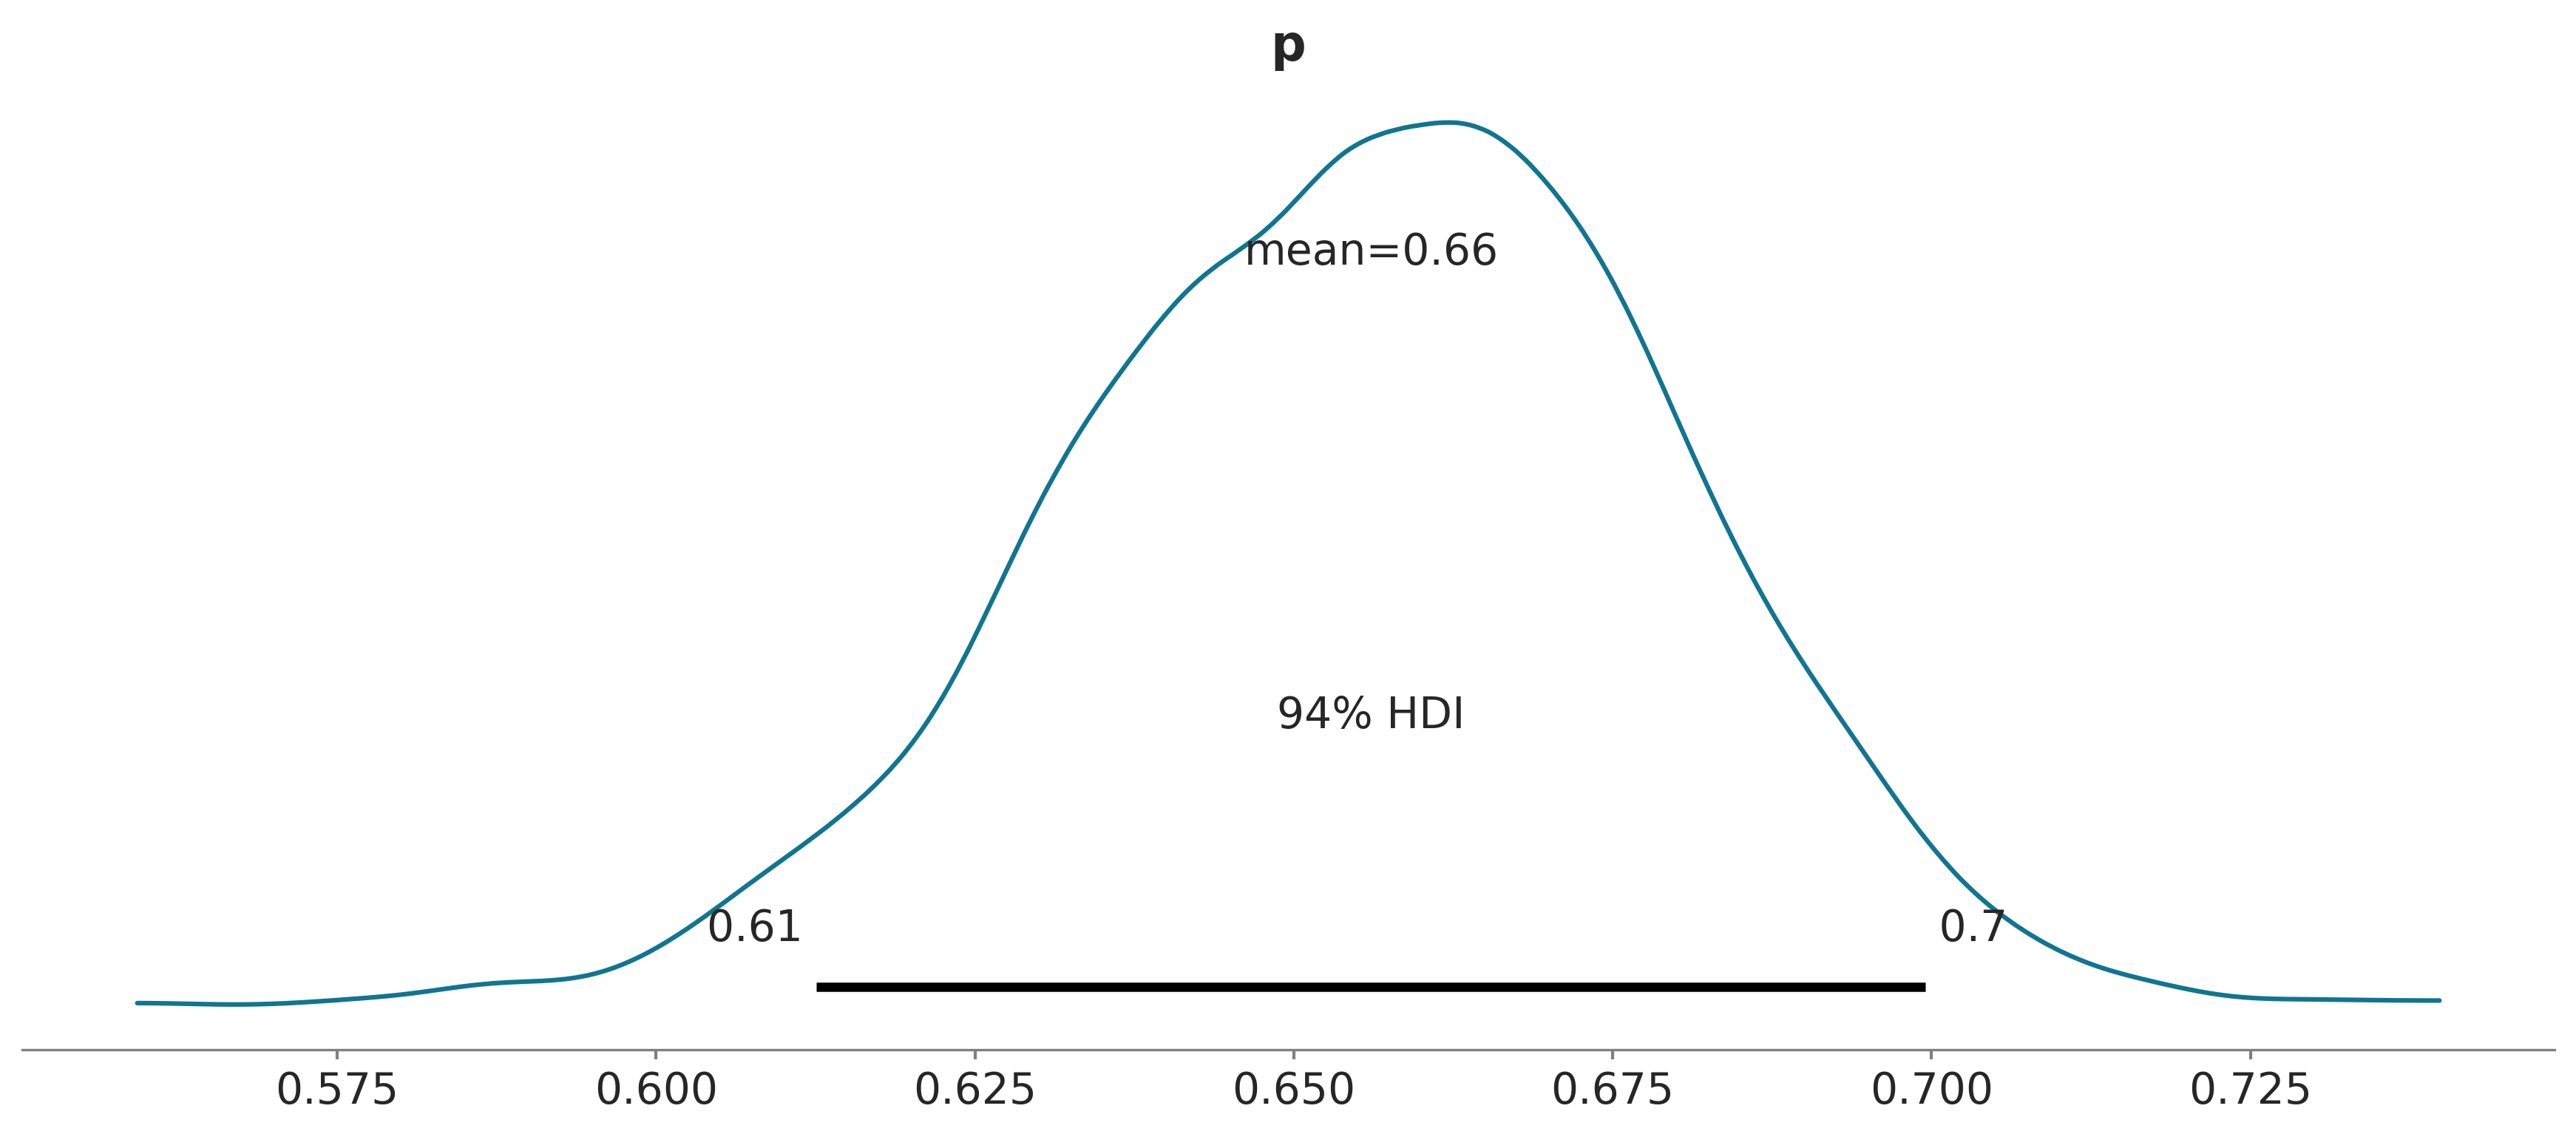

In [ ]:
az.plot_posterior(
    idata,
    var_names=["p"]
)

plt.show()


Ahora sí combinamos nuestro prior con los datos y obtenemos una distribución posterior para p. Pero todavía no terminamos: ahora queremos evaluar qué tipo de datos puede generar este modelo después de haber aprendido de los datos.



### 4. Predictiva posterior

In [ ]:
y_rep = (
    idata.posterior_predictive["y_obs"]
    .stack(sample=("chain", "draw"))
    .values
)


`y_rep` contiene muchas réplicas de nuestros datos.

Podemos comparar directamente una característica simple: la media.


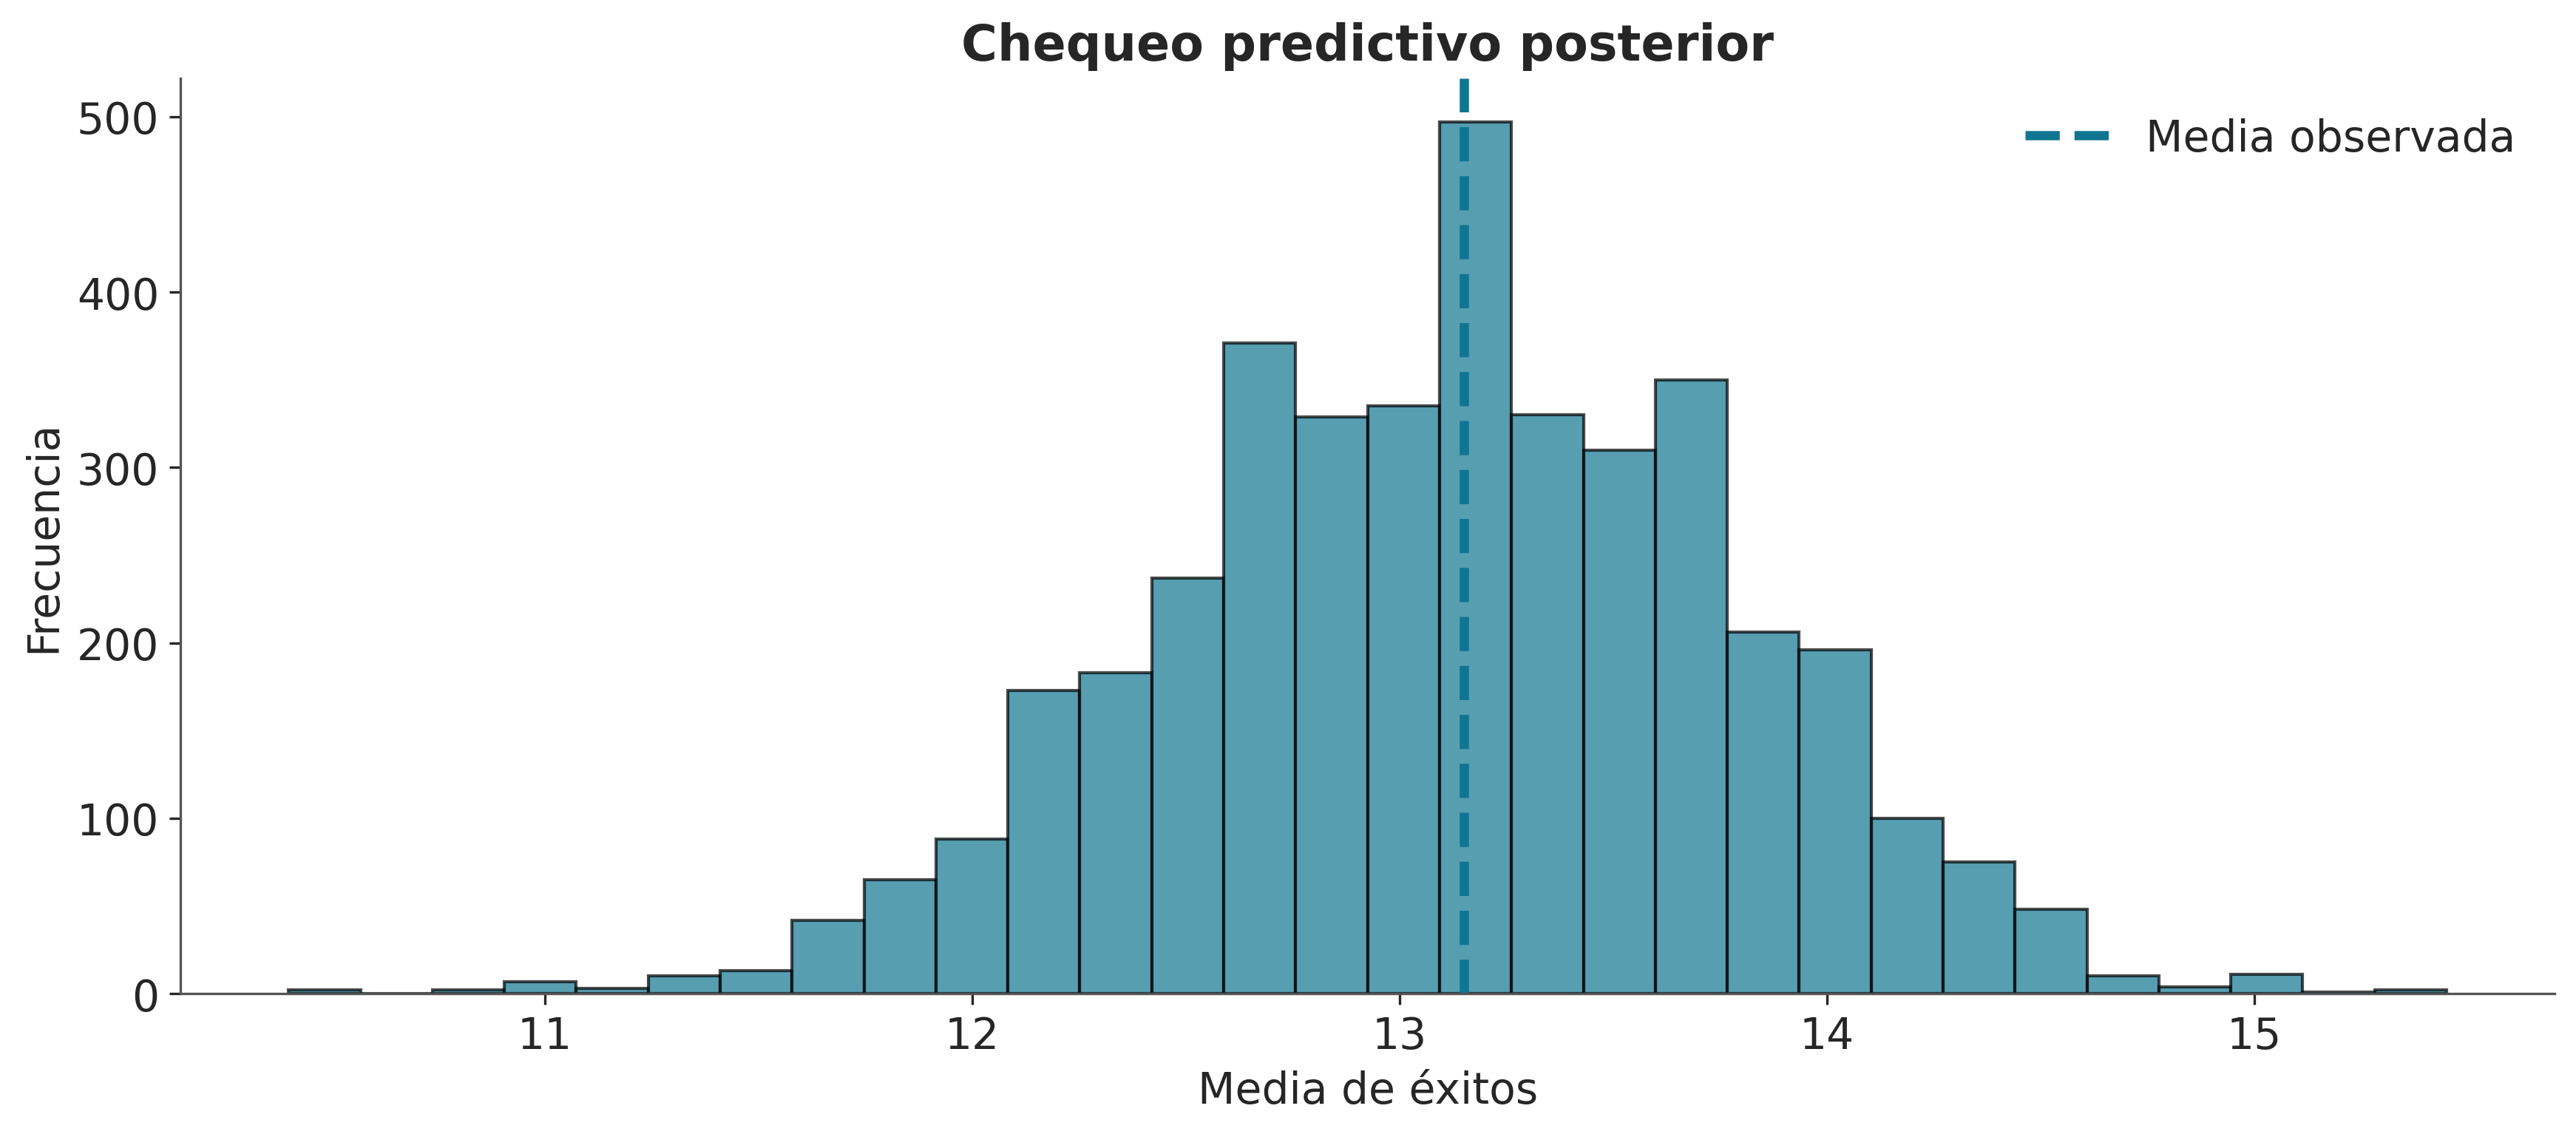

In [ ]:
media_observada = y.mean()

medias_simuladas = y_rep.mean(axis=0)

plt.hist(
    medias_simuladas,
    bins=30,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    media_observada,
    linestyle="--",
    linewidth=3,
    label="Media observada"
)

plt.xlabel("Media de éxitos")
plt.ylabel("Frecuencia")
plt.title("Chequeo predictivo posterior")

plt.legend()


plt.show()


En lugar de comparar cada dato individual, miramos una característica de los datos: la media. La línea representa la media que realmente observamos, y el histograma muestra las medias que generan muchas réplicas simuladas desde nuestro modelo.

Si la línea observada cae en una zona razonable de esta distribución, entonces el modelo es capaz de reproducir razonablemente esa característica.


5. Bayesian p-value



In [ ]:
p_B = np.mean(
    medias_simuladas <= media_observada
)

print(f"Bayesian p-value: {p_B:.3f}")


Bayesian p-value: 0.529



Calculamos la proporción de réplicas simuladas cuya media es menor o igual que la media observada.

Es decir:

$$p_B=P(T(\tilde{y​})\leq T(y)|y)$$




donde en este caso $T(y)=media(y)$


Esto no es un test de hipótesis. No vamos a decir que el resultado es significativo o no significativo. Lo estoy utilizando simplemente como una forma de resumir la posición de la característica observada dentro de las réplicas generadas por el modelo.

